# Q1

/Users/sparshkarna/dev/sem6/ml-lab/myenv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


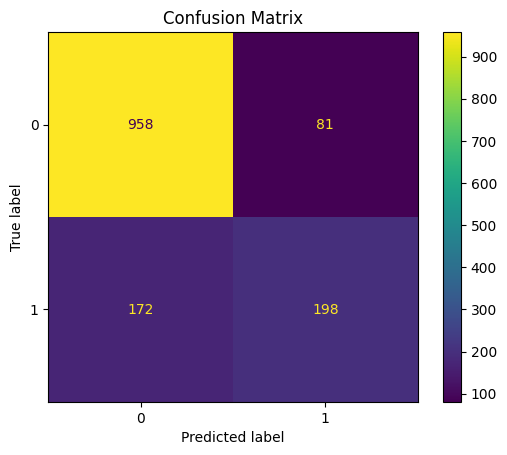

Predicted Probabilities for first 20 records:
[[0.35006867 0.64993133]
 [0.28855402 0.71144598]
 [0.98339557 0.01660443]
 [0.98109974 0.01890026]
 [0.20690873 0.79309127]
 [0.99295722 0.00704278]
 [0.98767182 0.01232818]
 [0.95317076 0.04682924]
 [0.94199071 0.05800929]
 [0.77264561 0.22735439]
 [0.94071168 0.05928832]
 [0.3954162  0.6045838 ]
 [0.87899803 0.12100197]
 [0.83233751 0.16766249]
 [0.97321629 0.02678371]
 [0.99211904 0.00788096]
 [0.42929569 0.57070431]
 [0.46816579 0.53183421]
 [0.98981301 0.01018699]
 [0.1980618  0.8019382 ]]
Accuracy Score: 0.8204


/Users/sparshkarna/dev/sem6/ml-lab/myenv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("churn.csv")
X = df.drop("Churn", axis=1)
y = df["Churn"]

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

model = LogisticRegression(max_iter=2000)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1172
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', model)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

probabilities = pipeline.predict_proba(X_test)
print("Predicted Probabilities for first 20 records:")
print(probabilities[:20])

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Q2

Model Accuracy: 84.70%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      2399
           1       0.82      0.83      0.83      1829

    accuracy                           0.85      4228
   macro avg       0.84      0.85      0.84      4228
weighted avg       0.85      0.85      0.85      4228



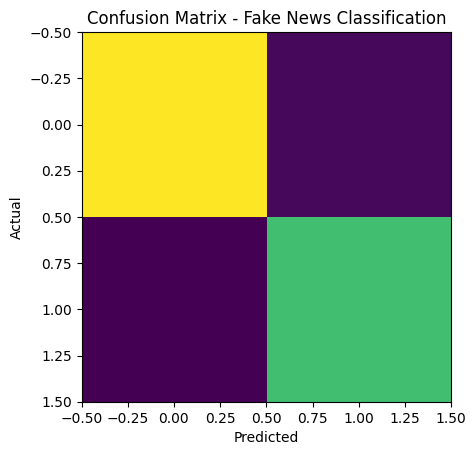

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.isnull().sum()

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train = tfidf.fit_transform(train_df['news'])
X_test = tfidf.transform(test_df['news'])
y_train = train_df['label']
y_test = test_df['label']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title('Confusion Matrix - Fake News Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()